In [1]:
import pandas as pd
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
# from sklearn.preprocessing import MinMaxScaler

2024-10-10 17:24:54.219975: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-10 17:24:54.692745: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
num_epochs = 10
batch_size = 2048
learning_rate = 0.001

In [3]:
AS_dataset = pd.read_csv('./dataset.csv', encoding='utf-8').sample(frac=1).reset_index(drop=True)
full_X = AS_dataset.loc[:,'freq':'W12'].to_numpy(dtype = np.float32)
full_y = AS_dataset.loc[:,'S11R':'S14I'].to_numpy(dtype = np.float32)
X_train, X_vali, y_train, y_vali = train_test_split(full_X, full_y, test_size=0.05, random_state=0)
X_train, _, y_train, _ = train_test_split(X_train, y_train, test_size=0.3, random_state=0)
dataset_train = tf.data.Dataset.from_tensor_slices((full_X, full_y))
dataset_train = dataset_train.shuffle(buffer_size=full_X.shape[0])
dataset_train = dataset_train.batch(batch_size)
dataset_train = dataset_train.prefetch(tf.data.experimental.AUTOTUNE)

2024-10-10 17:25:00.277515: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9604 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:17:00.0, compute capability: 7.5
2024-10-10 17:25:00.278058: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 9621 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:65:00.0, compute capability: 7.5


In [4]:
class MLP(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.dense1 = tf.keras.layers.Dense(units=512, activation=tf.nn.leaky_relu)
        self.dense2 = tf.keras.layers.Dense(units=1024, activation=tf.nn.leaky_relu)
        self.dense3 = tf.keras.layers.Dense(units=512, activation=tf.nn.leaky_relu)
        self.dense4 = tf.keras.layers.Dense(units=256, activation=tf.nn.leaky_relu)
        self.dense5 = tf.keras.layers.Dense(units=8)
    
#     @tf.function
    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        x = self.dense4(x)
        output = self.dense5(x)
        return output

In [5]:
model = MLP()
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

GT_struct = tf.constant([2.27248, 2.52657, 1.06926, 3.83355, 1.92307, 1.74249, 1.37051,  1.52846,  17.2486, 66.9054, 18.5276, 50.3882])
GT_X = tf.concat([tf.constant([[2.4], [2.5], [2.6]]), tf.repeat([GT_struct], 3, axis=0)], axis=1)
GT_S = tf.constant([[0.016, 0.075, 0.743, 0.343, 0.496, -0.185, -0.147, 0.005],
[-0.021, 0.003, 0.827, 0.089, 0.414, -0.333, -0.026, -0.018],
[-0.093, -0.046, 0.802, -0.177, 0.281, -0.444, 0.052, -0.109]])

2024-10-10 17:25:03.314615: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x561e56bbff50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-10-10 17:25:03.314638: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5
2024-10-10 17:25:03.314643: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5
2024-10-10 17:25:03.317606: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-10-10 17:25:04.474500: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8902
2024-10-10 17:25:04.590830: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


epoch:0
train mse:0.07809417694807053 rmse:0.2794533669948578 mae:0.22631721198558807 r2:0.3508526682853699 EC:0.32628193497657776
vali mse:0.0810055062174797 rmse:0.2846146523952484 mae:0.22953882813453674 r2:0.3273206949234009
GT mse:0.16226355731487274 rmse:0.40281951427459717 mae:0.3032071590423584 r2:-0.4647376537322998
epoch:9
train mse:0.014237776398658752 rmse:0.11932215094566345 mae:0.08942998200654984 r2:0.881834864616394 EC:0.9011673331260681
vali mse:0.017541110515594482 rmse:0.13244286179542542 mae:0.10033239424228668 r2:0.8543365001678467
GT mse:0.007004585117101669 rmse:0.08369340002536774 mae:0.061652377247810364 r2:0.9367702603340149


ValueError: x and y must have same first dimension, but have shapes (16,) and (2,)

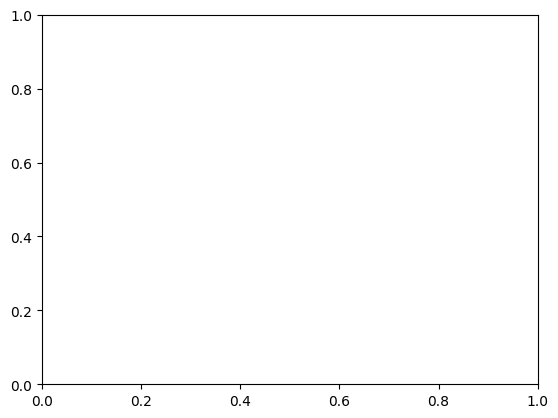

In [6]:
showX = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 149]
showY1 = []
showY2 = []

for epoch_index in range(num_epochs):
    for X, y in dataset_train:
        with tf.GradientTape() as tape:
            y_pred = model(X)
            tr_mse = tf.reduce_mean(tf.square(y_pred - y))
        grads = tape.gradient(tr_mse, model.variables)
        optimizer.apply_gradients(grads_and_vars=zip(grads, model.variables))
    if epoch_index % 10 == 0 or epoch_index == num_epochs - 1:
        tr_EC = tf.reduce_mean(tf.reduce_sum(tf.square(y_pred), axis=1))
        tr_rmse = tf.sqrt(tr_mse)
        tr_mae = tf.reduce_mean(tf.abs(y_pred - y))
        tr_r2 = 1 - tf.reduce_sum(tf.square(y_pred - y)) / tf.reduce_sum(tf.square(y - tf.reduce_mean(y)))
        print("epoch:{}".format(epoch_index))
        print("train mse:{} rmse:{} mae:{} r2:{} EC:{}".format(tr_mse, tr_rmse, tr_mae, tr_r2, tr_EC))
        y_v_p = model(X_vali)
        va_mse = tf.reduce_mean(tf.square(y_v_p - y_vali))
        va_rmse = tf.sqrt(va_mse)
        va_mae = tf.reduce_mean(tf.abs(y_v_p - y_vali))
        va_r2 = 1 - tf.reduce_sum(tf.square(y_v_p - y_vali)) / tf.reduce_sum(tf.square(y_vali - tf.reduce_mean(y_vali)))
        print("vali mse:{} rmse:{} mae:{} r2:{}".format(va_mse, va_rmse, va_mae, va_r2))
        GT_y = model(GT_X)
        # GT_loss = loss_func(GT_y[0:1], GT_y[1:2], GT_y[2:3], GT_y[3:4], GT_y[4:5], GT_y[5:6]) + loss_func(GT_y[6:7], GT_y[7:8], GT_y[8:9], GT_y[9:10], GT_y[10:11], GT_y[11:12])
        GT_mse = tf.reduce_mean(tf.square(GT_y - GT_S))
        GT_rmse = tf.sqrt(GT_mse)
        GT_mae = tf.reduce_mean(tf.abs(GT_y - GT_S))
        GT_r2 = 1 - tf.reduce_sum(tf.square(GT_y - GT_S)) / tf.reduce_sum(tf.square(GT_S - tf.reduce_mean(GT_S)))
        print("GT mse:{} rmse:{} mae:{} r2:{}".format(GT_mse, GT_rmse, GT_mae, GT_r2))
        showY1.append(tr_r2)
        showY2.append(va_r2)
plt.plot(showX, showY1)
plt.plot(showX, showY2)
plt.ylim(0, 1)
plt.show()

In [7]:
tf.saved_model.save(model, './models')

INFO:tensorflow:Assets written to: ./models/assets


INFO:tensorflow:Assets written to: ./models/assets


In [6]:
model = tf.saved_model.load('./models')

In [17]:
def dgn_obj(s_para, dis = False):
    E = tf.square(s_para)
    E11 = E[:,0] + E[:,1]
    E21 = E[:,2] + E[:,3]
    E31 = E[:,4] + E[:,5]
    E41 = E[:,6] + E[:,7]
    l1 = E11 - E21 - E31 + E41
    l2 = tf.abs(E21 / (E31 + E21) - 0.7)
    l3 = tf.abs(tf.math.atan2(s_para[:,3], s_para[:,2]) - tf.math.atan2(s_para[:,5], s_para[:,4]) - np.pi / 4)
    l4 = tf.abs(tf.reduce_sum(E, axis=1) - 1)
    loss = l1 + l2 + l3 + l4
    if dis == True:
        print("l1", l1.numpy()[0])
        print("l2", l2.numpy()[0])
        print("l3", l3.numpy()[0])
        print("l4", l4.numpy()[0])
    return loss
def loss_func(s1, s2, s3, dis = False):
    # 21和31的方差
    # var = tf.reduce_sum(tf.nn.moments(tf.stack([s1, s2, s3], axis=1), [1])[1][:, 2: 6], axis=-1)
    if dis == True:
        print("var", var.numpy()[0])
    return dgn_obj(s1, dis) + dgn_obj(s2, dis) + dgn_obj(s3, dis)

In [18]:
num_nodes = 10000
num_node_epochs = 1000

In [19]:
opt = tf.keras.optimizers.legacy.Adam(learning_rate=0.01)

mmin = np.min(full_X[: , 1: ], axis=0)
mmax = np.max(full_X[: , 1: ], axis=0)

structure = tf.Variable(np.random.uniform(mmin, mmax, (num_nodes, 12)), dtype=tf.float32)

freq1 = tf.ones([num_nodes, 1]) * 2.4
freq2 = tf.ones([num_nodes, 1]) * 2.5
freq3 = tf.ones([num_nodes, 1]) * 2.6

In [20]:
bestLoss = 10
bestStructure = 0

In [21]:
def check(structure):
    # inva_place1 = tf.where(structure[:,:8] < 1)
    inva_place1 = tf.where(tf.logical_or(structure[:,:8] < 1, structure[:,:8] > 5))
    structure = tf.tensor_scatter_nd_update(structure, [inva_place1], [np.random.uniform(mmin[inva_place1[:,1]], mmax[inva_place1[:,1]], (inva_place1.shape[0]))])
    
    # inva_place2 = tf.where(structure[:,8:] < 4) + [0, 8]
    inva_place2 = tf.where(tf.logical_or(structure[:,8:] < 4, structure[:,8:] > 100)) + [0, 8]
    structure = tf.tensor_scatter_nd_update(structure, [inva_place2], [np.random.uniform(mmin[inva_place2[:,1]], mmax[inva_place2[:,1]], (inva_place2.shape[0]))])
    
    return tf.Variable(structure)
    
    # structure[j] = tf.Variable(tf.tensor_scatter_nd_update(structure[j], [nega_place], [np.random.uniform(0, 1, (nega_place.shape[0]))]))

In [22]:
for i in range(num_node_epochs):
    with tf.GradientTape(watch_accessed_variables=False) as tape:
        tape.watch(structure)
        y_pred1 = model(tf.concat([freq1, structure], axis = 1))
        y_pred2 = model(tf.concat([freq2, structure], axis = 1))
        y_pred3 = model(tf.concat([freq3, structure], axis = 1))
        loss = loss_func(y_pred1, y_pred2, y_pred3)
    minLoss = tf.reduce_min(loss).numpy()
    minIndex = tf.argmin(loss).numpy()
    minS = structure[minIndex].numpy()
    grads = tape.gradient(loss, structure)
    opt.apply_gradients(grads_and_vars=zip([grads], [structure]))
    structure = check(structure)
    if minLoss < bestLoss:
        bestLoss = minLoss
        bestStructure = minS
        # bestStructure = data_loader.mmX.inverse_transform([minS[0]])[0]
        print(minIndex)
        print(i, bestLoss)
        print(" ".join(map(str, bestStructure)))
        print()

1165
0 -0.6273702
2.724463 5.125721 1.0765163 3.5384667 1.3892674 5.2877865 2.4071794 5.4344354 54.064114 62.235554 9.352673 82.36806

1836
1 -0.64782524
4.8939743 4.2260656 2.2785928 2.2223518 4.194383 1.0371577 1.0720154 1.4081274 50.586617 61.16203 17.89557 14.793627

1836
2 -0.6620099
4.901416 4.2335067 2.2711518 2.229793 4.201824 1.0445988 1.0794568 1.4006878 50.59406 61.154594 17.903011 14.801068

1836
3 -0.6743672
4.907804 4.2398944 2.264764 2.2361813 4.208212 1.0509866 1.0858449 1.3943009 50.60045 61.16098 17.909399 14.807456

1836
4 -0.6858427
4.913615 4.245705 2.258953 2.2419925 4.214023 1.0567976 1.0916561 1.3884908 50.60626 61.16679 17.91521 14.813268

1836
5 -0.6971089
4.9190702 4.2511597 2.2534986 2.2474473 4.2194777 1.0622523 1.097111 1.3830373 50.611713 61.172245 17.920666 14.818723

1836
6 -0.7081088
4.9242916 4.2563806 2.2482777 2.2526684 4.2246985 1.0674733 1.1023321 1.3778179 50.616936 61.177467 17.925886 14.823944

1836
7 -0.71883607
4.929355 4.261444 2.2432141 2.2

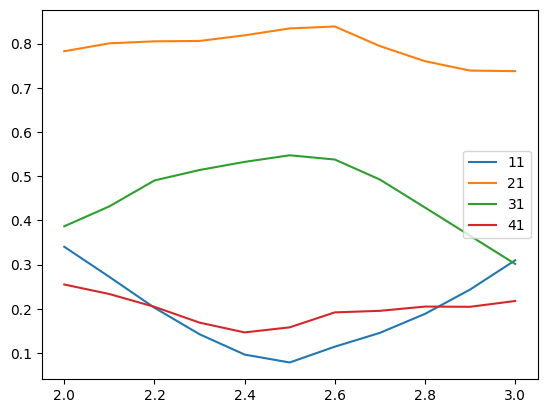

In [26]:
# 画图
fig_freq = tf.linspace(2.0, 3.0, 11)
fig_x = tf.concat([tf.reshape(fig_freq, (-1, 1)), tf.tile([bestStructure], [11, 1])], axis=-1)
fig_y = model(fig_x)
E = tf.square(fig_y)
M11 = tf.sqrt(E[:,0] + E[:,1])
M21 = tf.sqrt(E[:,2] + E[:,3])
M31 = tf.sqrt(E[:,4] + E[:,5])
M41 = tf.sqrt(E[:,6] + E[:,7])
plt.figure()
plt.plot(fig_freq, M11, label='11')
plt.plot(fig_freq, M21, label='21')
plt.plot(fig_freq, M31, label='31')
plt.plot(fig_freq, M41, label='41')
plt.legend()
plt.show()

In [27]:
# S4P
l = fig_y.numpy().tolist()
for i in range(len(l)):
    print(round(fig_freq.numpy()[i]*10,0) / 10, end="\t")
    print(l[i][0], l[i][1], "0\t" * 6, sep="\t")
    print(l[i][2], l[i][3], "0\t" * 6, sep="\t")
    print(l[i][4], l[i][5], "0\t" * 6, sep="\t")
    print(l[i][6], l[i][7], "0\t" * 6, sep="\t")

2.0	-0.23639854788780212	0.2447350025177002	0	0	0	0	0	0	
-0.7350830435752869	-0.26911312341690063	0	0	0	0	0	0	
-0.3825279772281647	0.05626401677727699	0	0	0	0	0	0	
0.0765700712800026	0.24315015971660614	0	0	0	0	0	0	
2.1	-0.17741301655769348	0.20637249946594238	0	0	0	0	0	0	
-0.7718541026115417	-0.21275357902050018	0	0	0	0	0	0	
-0.40498605370521545	0.1495475471019745	0	0	0	0	0	0	
0.07901004701852798	0.21957461535930634	0	0	0	0	0	0	
2.2	-0.12214018404483795	0.16131186485290527	0	0	0	0	0	0	
-0.7917973399162292	-0.14647488296031952	0	0	0	0	0	0	
-0.420771986246109	0.25173869729042053	0	0	0	0	0	0	
0.07729033380746841	0.18921367824077606	0	0	0	0	0	0	
2.3	-0.07889901101589203	0.11846374720335007	0	0	0	0	0	0	
-0.804029643535614	-0.05699090659618378	0	0	0	0	0	0	
-0.39192143082618713	0.3325906991958618	0	0	0	0	0	0	
0.09573904424905777	0.1388210505247116	0	0	0	0	0	0	
2.4	-0.059175390750169754	0.07598089426755905	0	0	0	0	0	0	
-0.8181020617485046	0.03482337296009064	0	0	0	0	0	0	
-0.35696759819984436	

In [28]:
MP_X = tf.concat([tf.constant([[2.4],[2.5],[2.6]]), tf.tile([bestStructure], [3, 1])], axis=-1)
GT_X = tf.concat([tf.constant([[2.4],[2.5],[2.6]]), tf.tile([GT_struct], [3, 1])], axis=-1)
MP_y = model(MP_X)
GT_y = model(GT_X)
print("MP")
MP_loss = loss_func(MP_y[0:1], MP_y[1:2], MP_y[2:3], dis=True)
print(MP_loss)
print("GT")
GT_loss = loss_func(GT_y[0:1], GT_y[1:2], GT_y[2:3], dis=True)
print(GT_loss)

MP


NameError: name 'var' is not defined

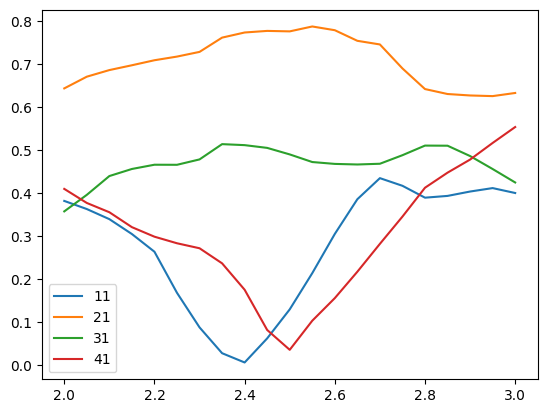

In [29]:
# 画图
fig_freq = tf.linspace(2.0, 3.0, 21)
fig_x = tf.concat([tf.reshape(fig_freq, (-1, 1)), tf.tile([GT_struct], [21, 1])], axis=-1)
fig_y = model(fig_x)
E = tf.square(fig_y)
M11 = tf.sqrt(E[:,0] + E[:,1])
M21 = tf.sqrt(E[:,2] + E[:,3])
M31 = tf.sqrt(E[:,4] + E[:,5])
M41 = tf.sqrt(E[:,6] + E[:,7])
plt.figure()
plt.plot(fig_freq, M11, label='11')
plt.plot(fig_freq, M21, label='21')
plt.plot(fig_freq, M31, label='31')
plt.plot(fig_freq, M41, label='41')
plt.legend()
plt.show()